# Level 5 — Data Mining Challenge: *The 1,000-Pick*

**규칙**: Set B (이미지 + 라벨 공개) 에서 **최대 1,000장** 을 선택하여 학습 셋에 추가하고, best 모델을 다시 학습하세요.

> **Set B 의 라벨이 공개되어 있다는 점에 주의**하세요. 본 Level 의 평가 본질은 "*주어진 풀에서 어떤 1,000장이 가장 가치 있는가*" — 즉, 라벨을 알고 있다고 가정한 상태에서의 효율적인 부분집합 선택입니다.

**본 PA에서 가장 큰 비중 (25%)** 을 차지하는 Level 입니다. 어떤 *알고리즘* 으로 1,000장을 골랐는지 — 그 *근거* — 가 변별력의 본진입니다. Curation Report 로 정리합니다.

채점 메트릭:
$$\text{DI} = \frac{\text{Avg-MF1}(\text{본인 picks}) - \text{Avg-MF1}(\text{random picks})}{\text{Avg-MF1}(\text{random picks})}$$

## 검토해 볼 만한 전략

| 전략 | 핵심 아이디어 | Set B 라벨 활용 |
|---|---|---|
| 클래스 균형 (Class Balancing) | Set A 에서 부족한 속성 클래스 (foggy / dawn-dusk 등) 를 채워 넣음 | ✅ 라벨로 직접 필터링 |
| Hard Example Mining | base 모델의 confidence 가 낮은 / 예측이 라벨과 다른 이미지를 우선 선택 | ✅ 모델 예측 vs 정답 비교 |
| 다양성 (Core-Set) | Set B 의 feature space 를 가장 잘 커버하는 부분집합 선택 (k-center / clustering) | 라벨 무관 |
| 결합 커버리지 | 속성 *조합* 의 균형을 맞춤 — 예: (snowy & night), (rainy & residential) | ✅ 라벨로 조합 카운트 |
| Loss 기반 | Set B 이미지에 대한 학습 직전 loss 가 큰 샘플 우선 | ✅ 라벨 필요 |

위 전략들을 결합/응용/대체할 수 있습니다. **Curation Report 에 본인의 의사결정 근거를 명확히 기술** 하세요.

**산출물**: `level5_picks.json` — 선택한 image_id 리스트 (이미지별 메타데이터 포함 가능).

In [1]:
import os
import sys

# # 1. 코랩 환경에서 레포지토리가 클론되지 않은 경우에만 Clone 진행
# repo_name = "2026-HYU-AUE8088-PA2"
# if not os.path.exists(f"/content/{repo_name}"):
#     !git clone https://github.com/IRCVLab/2026-HYU-AUE8088-PA2.git

# # 2. 작업 디렉토리를 레포지토리의 최상단(Root)으로 변경
# %cd /content/{repo_name}

# 프로젝트 루트를 sys.path에 추가 (src 모듈 인식용)
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

%load_ext autoreload
%autoreload 2

# 의존성 설치 (이미 설치된 패키지는 빠르게 skip)
!pip install -q -r ../requirements.txt

In [2]:
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader

from src.utils.seed import set_seed, seed_worker
from src.utils.transforms import train_transform, eval_transform
from src.utils.trainer import MultiTaskTrainer, TrainConfig
from src.utils.wandb_logger import WandbLogger
from src.utils.metrics import collect_predictions, confusion_matrices, CLASS_NAMES
from src.utils.submission import write_submission
from src.datasets.bdd_attr import BDDAttrDataset, ATTRIBUTES, NUM_CLASSES
from src.models.resnet import resnet18

SEED = 42
set_seed(SEED, deterministic=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
import wandb; wandb.login()   # API key 입력

WANDB_PROJECT = "aue8088-pa2"   # 비활성화하려면 None
STRATEGY_NAME = "top1k-uncertainty"   # 본인 전략명 (Run 이름에 들어감)
WANDB_TAGS    = ["level5", STRATEGY_NAME]

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/jisang/.netrc.
wandb: Currently logged in as: journeyofbabo (journeyofbabo-hanyang-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [4]:
# --- 데이터셋 자동 다운로드 (Google Drive) ---------------------------------
# ../data/set_a 가 없으면 zip 을 받아 상위 폴더에 압축 해제 → ../data/set_a, ../data/set_b 생성.
import os, sys, zipfile, subprocess

GDRIVE_FILE_ID = "1L7YC70QlO87aIbE5lbtQ94HUINJijBKK"
ZIP_PATH   = "../aue8088_pa2_data.zip"
EXTRACT_TO = ".."   # zip 내부 최상위가 data/ 이므로 상위 폴더에 풀면 ../data/... 가 됨
DATA_ROOT = "../data/set_a"

if not os.path.isdir(DATA_ROOT):
    try:
        import gdown
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gdown"], check=True)
        import gdown

    if not os.path.exists(ZIP_PATH):
        print("데이터셋 zip 다운로드 중...")
        gdown.download(id=GDRIVE_FILE_ID, output=ZIP_PATH, quiet=False)

    print("압축 해제 중...")
    with zipfile.ZipFile(ZIP_PATH) as zf:
        zf.extractall(EXTRACT_TO)
    print(f"완료 → {DATA_ROOT}")
else:
    print(f"데이터셋이 이미 존재합니다 → {DATA_ROOT}")
# --------------------------------------------------------------------------


데이터셋이 이미 존재합니다 → ../data/set_a


In [ ]:
# 1단계 — best base 모델로 Set B 의 모든 이미지를 score.
model = resnet18().to(device)
ckpt = torch.load("../checkpoints/level3_best_30ep.pth", map_location=device, weights_only=False)
model.load_state_dict(ckpt["state_dict"])
model.eval()
print("Loaded level3_best_30ep (Avg-MF1=0.6626)")

set_b = BDDAttrDataset("../data/set_b", split="mining", transform=eval_transform())
loader_b = DataLoader(set_b, batch_size=128, shuffle=False, num_workers=2)

preds_b, probs_b, _, ids_b = collect_predictions(model, loader_b, device)

# 이미지별 불확실성 (uncertainty) 계산: 1 - max-softmax 를 3개 head 평균.
max_probs = np.stack([probs_b[a].max(axis=-1) for a in ATTRIBUTES], axis=1)
uncertainty = 1.0 - max_probs.mean(axis=1)
print(f"Set B 총 이미지 수: {len(set_b)}")
print(f"uncertainty shape: {uncertainty.shape}, mean={uncertainty.mean():.3f}")

In [8]:
# 2단계 — 본인의 선별 알고리즘을 설계하세요.
#
# Set B 의 정답 라벨은 set_b 의 BDDAttrDataset (split="mining") 에 이미 채워져 있습니다.
# preds_b (모델 예측) 와 set_b 의 sample.weather/scene/timeofday (정답) 를 함께 활용 가능.
#
# 아래는 placeholder (top-1000 most-uncertain). 본인 구현으로 교체하세요.
# Tip: 단일 신호보다 여러 신호를 결합하는 편이 보통 더 좋은 성능을 냅니다. 예시:
#   score_i = lam * uncertainty_i  +  (1 - lam) * is_rare_class_i

import json
import numpy as np
from tqdm import tqdm
from collections import Counter
from torch.utils.data import DataLoader, Subset
from src.datasets.bdd_attr import WEATHER_CLASSES, SCENE_CLASSES, TIMEOFDAY_CLASSES

K           = 1000   # 최종 선택할 이미지 수
CANDIDATE_K = 3000   # K-center 적용 전 1차 후보군 크기

# ── 1. Entropy 기반 Uncertainty 계산 ──────────────────────────────────────────
# max-softmax(uncertainty = 1 - max_prob)보다 entropy가 더 정밀.
# 이유: [0.6, 0.3, 0.1]과 [0.6, 0.2, 0.1, 0.05, 0.03, 0.02]는
#       max-softmax로 같은 값이지만 entropy는 후자가 더 높음 (더 불확실).
# H = -Σ p_i × log(p_i)  → 확률이 고르게 퍼질수록 높음

def entropy(probs):
    probs = np.clip(probs, 1e-8, 1.0)
    return -(probs * np.log(probs)).sum(axis=-1)

H_weather   = entropy(probs_b["weather"])     # (N,)
H_scene     = entropy(probs_b["scene"])       # (N,)
H_timeofday = entropy(probs_b["timeofday"])   # (N,)
ent_mean = (H_weather + H_scene + H_timeofday) / 3   # 3개 head 평균

# ── 2. Class-aware Weight 계산 ────────────────────────────────────────────────
# 이 데이터셋에서 Set A의 클래스 분포:
#   weather:   snowy=200, rainy=400, foggy=0 (Set B에도 없음)
#   scene:     residential=562
#   timeofday: dawn/dusk=392
# Macro-F1은 소수 클래스 성능이 낮으면 전체 점수를 크게 깎음.
# → 희귀 클래스 이미지일수록 높은 가중치를 부여해 우선 선택.
# 가중치는 Set A 샘플 수 역비례로 설정.

WEATHER_W   = {0: 0.3,  # clear         3100장
               1: 0.9,  # overcast        800장
               2: 1.6,  # rainy           400장
               3: 2.5,  # snowy           200장 ← 가장 부족
               4: 0.0,  # foggy             0장 (Set B에도 없으므로 제외)
               5: 1.3}  # partly cloudy   500장

SCENE_W     = {0: 0.3,  # city street   3052장
               1: 0.8,  # highway       1386장
               2: 2.0}  # residential    562장 ← 부족

TIMEOFDAY_W = {0: 0.3,  # daytime       2479장
               1: 0.6,  # night         2129장
               2: 3.0}  # dawn/dusk      392장 ← 매우 부족

# 이미지 하나의 class_weight = 3개 속성 가중치의 합
# 예: (snowy + residential + dawn/dusk) → 4.0+2.0+3.0 = 9.0  ← 최고
# 예: (clear + city street + daytime)   → 0.3+0.3+0.3 = 0.9  ← 최저
class_weights = np.array([
    WEATHER_W[s.weather] + SCENE_W[s.scene] + TIMEOFDAY_W[s.timeofday]
    for s in set_b.samples
])

# ── 3. 1차 Score → 상위 3,000장 후보 추출 ────────────────────────────────────
# S1 = class_weight × entropy
# 희귀 클래스이면서 + 모델이 불확실하게 예측한 이미지가 높은 점수
s1_scores    = class_weights * ent_mean
candidate_idx = np.argsort(-s1_scores)[:CANDIDATE_K]
print(f"1차 후보군: {CANDIDATE_K}장 (S1 score 상위)")

# ── 4. ResNet Backbone Feature 추출 (후보 3,000장) ───────────────────────────
# K-center greedy는 feature space에서 거리를 계산함.
# ResNet의 avgpool 출력(512-dim 벡터)을 이미지 표현으로 사용.
# → 비슷한 장면/구도의 이미지는 feature space에서 가까이 위치.

feat_list = []
hook_out  = {}

def _hook(module, inp, out):
    # avgpool 출력: (B, 512, 1, 1) → squeeze → (B, 512)
    hook_out["feat"] = out.squeeze(-1).squeeze(-1)

hook = model.avgpool.register_forward_hook(_hook)

cand_loader = DataLoader(
    Subset(set_b, candidate_idx),
    batch_size=128, shuffle=False, num_workers=2, pin_memory=True
)
model.eval()
with torch.no_grad():
    for batch in tqdm(cand_loader, desc="Feature 추출"):
        _ = model(batch["image"].to(device))
        feat_list.append(hook_out["feat"].cpu().numpy())

hook.remove()
features = np.concatenate(feat_list, axis=0)   # (3000, 512)
print(f"Feature 추출 완료: {features.shape}")

# ── 5. K-Center Greedy → 최종 1,000장 선택 ───────────────────────────────────
# 아이디어: "이미 선택된 이미지들과 가장 멀리 있는 이미지를 하나씩 추가"
# → 비슷한 이미지가 몰리지 않고 feature space를 고르게 커버.
#
# 알고리즘:
#   1. 첫 번째: S1 score 최고인 이미지 (candidate_idx[0])
#   2. 반복:
#      - 각 이미지와 "선택된 집합" 사이의 최소 거리 계산
#        min_dist[i] = min(||feat[i] - feat[s]|| for s in selected)
#      - min_dist가 가장 큰 이미지 선택 → 아직 커버 안 된 영역

def k_center_greedy(feats, k):
    N = len(feats)
    selected  = [0]   # 첫 번째: S1 최고점 (이미 정렬된 상태)
    min_dists = np.full(N, np.inf)

    for _ in tqdm(range(k - 1), desc="K-Center Greedy"):
        last     = feats[selected[-1]]
        # 마지막으로 추가된 이미지와의 L2 거리
        dists    = np.linalg.norm(feats - last, axis=1)
        # 최소 거리 갱신 (더 가까운 기준점이 생기면 업데이트)
        min_dists = np.minimum(min_dists, dists)
        # 이미 선택된 인덱스는 제외
        min_dists[selected] = -1
        # 선택된 집합에서 가장 멀리 있는 이미지 추가
        selected.append(int(np.argmax(min_dists)))

    return selected

selected_in_cand = k_center_greedy(features, K)
# candidate 내 인덱스 → Set B 전체 인덱스로 변환
final_idx = candidate_idx[selected_in_cand]
print(f"\n최종 선택: {len(final_idx)}장")

# ── 6. Picks 저장 ─────────────────────────────────────────────────────────────
picks = []
for i in final_idx:
    s = set_b.samples[i]
    picks.append({
        "image_id":  s.image_id,
        "weather":   int(s.weather),
        "scene":     int(s.scene),
        "timeofday": int(s.timeofday),
        "s1_score":  round(float(s1_scores[i]), 4),
    })

with open("../level5_picks.json", "w") as f:
    json.dump({
        "strategy": (
            "Set A의 클래스 분포를 기반으로 희귀 클래스(snowy/dawn-dusk/residential)에 "
            "높은 가중치를 부여하고, 멀티태스크 Entropy 불확실성을 곱한 1차 점수로 "
            "상위 3,000장을 추린 뒤, ResNet backbone feature 공간에서 "
            "K-Center Greedy를 적용하여 시각적 다양성을 보장하는 최종 1,000장을 선택하였다."
        ),
        "num_picks": len(picks),
        "picks":     picks,
    }, f, indent=2)
print(f"Saved {len(picks)} picks → ../level5_picks.json")

# ── 7. 선택 결과 분포 확인 ────────────────────────────────────────────────────
print("\n=== 선택된 1,000장 분포 (Set A와 비교) ===")
SET_A_CNT = {
    "weather":   [3100, 800, 400, 200, 0, 500],
    "scene":     [3052, 1386, 562],
    "timeofday": [2479, 2129, 392],
}
for attr, classes in [("weather",   WEATHER_CLASSES),
                       ("scene",     SCENE_CLASSES),
                       ("timeofday", TIMEOFDAY_CLASSES)]:
    cnt = Counter(p[attr] for p in picks)
    print(f"\n[{attr}]")
    for i, cls in enumerate(classes):
        n_picks = cnt.get(i, 0)
        n_seta  = SET_A_CNT[attr][i]
        bar     = "█" * (n_picks // 10)
        print(f"  {cls:15s}: picks={n_picks:4d}  SetA={n_seta:4d}  {bar}")

1차 후보군: 3000장 (S1 score 상위)


Feature 추출:   0%|          | 0/24 [00:00<?, ?it/s]

Feature 추출: 100%|██████████| 24/24 [00:01<00:00, 23.04it/s]


Feature 추출 완료: (3000, 512)


K-Center Greedy: 100%|██████████| 999/999 [00:00<00:00, 2120.15it/s]


최종 선택: 1000장
Saved 1000 picks → ../level5_picks.json

=== 선택된 1,000장 분포 (Set A와 비교) ===

[weather]
  clear          : picks= 194  SetA=3100  ███████████████████
  overcast       : picks= 140  SetA= 800  ██████████████
  rainy          : picks= 153  SetA= 400  ███████████████
  snowy          : picks= 417  SetA= 200  █████████████████████████████████████████
  foggy          : picks=   0  SetA=   0  
  partly cloudy  : picks=  96  SetA= 500  █████████

[scene]
  city street    : picks= 463  SetA=3052  ██████████████████████████████████████████████
  highway        : picks= 264  SetA=1386  ██████████████████████████
  residential    : picks= 273  SetA= 562  ███████████████████████████

[timeofday]
  daytime        : picks= 451  SetA=2479  █████████████████████████████████████████████
  night          : picks= 110  SetA=2129  ███████████
  dawn/dusk      : picks= 439  SetA= 392  ███████████████████████████████████████████


In [9]:
# 3단계 — Set A + 본인이 고른 picks 로 재학습. 학습 메트릭은 wandb 로 자동 로깅.
from src.losses.imbalanced import FocalLoss, ClassBalancedLoss
from src.augment.mix import mixup_data, mixed_loss
from tqdm import tqdm

extra = [(p["image_id"], p["weather"], p["scene"], p["timeofday"]) for p in picks]
train_aug = BDDAttrDataset("../data/set_a", "train", transform=train_transform(), extra_picks=extra)
val_ds    = BDDAttrDataset("../data/set_a", "val",   transform=eval_transform())

print(f"Train set: {len(train_aug)} samples (Set A + {len(extra)} picks)")

g = torch.Generator(); g.manual_seed(SEED)
loader_tr  = DataLoader(train_aug, batch_size=64, shuffle=True, num_workers=2,
                        worker_init_fn=seed_worker, generator=g, pin_memory=True)
loader_val = DataLoader(val_ds,    batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

# Level 3 best 체크포인트에서 파인튜닝 (scratch보다 유리)
set_seed(SEED, deterministic=True)
model2 = resnet18().to(device)
base = torch.load("../checkpoints/level3_best_30ep.pth", map_location=device, weights_only=False)
model2.load_state_dict(base["state_dict"])
print("Fine-tuning from level3_best_30ep")

EPOCHS = 25
LR     = 5e-5   # 파인튜닝이므로 낮은 LR 유지

# Level 3에서 검증된 loss 조합 재사용
samples_s = train_aug.class_counts("scene")
loss_fns  = {
    "weather":   FocalLoss(gamma=2.0).to(device),
    "scene":     ClassBalancedLoss(samples_s).to(device),
    "timeofday": nn.CrossEntropyLoss(),
}

optim = torch.optim.AdamW(model2.parameters(), lr=LR, weight_decay=5e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=EPOCHS)

logger = WandbLogger(
    project=WANDB_PROJECT,
    run_name=f"level5-{STRATEGY_NAME}",
    config={
        "backbone": "resnet18", "pretrained": "level3_best_30ep",
        "strategy": STRATEGY_NAME, "num_picks": len(picks),
        "epochs": EPOCHS, "batch": 64, "lr": LR, "seed": SEED,
        "loss": {"weather": "focal_g2.0", "scene": "cb_loss", "timeofday": "ce"},
        "augment": "mixup_alpha0.2",
    },
    tags=WANDB_TAGS,
)
trainer = MultiTaskTrainer(model2, optim, sched, loss_fns, device,
                           TrainConfig(epochs=EPOCHS), logger=logger)

history = {"train_loss": [], "val_avg_mf1": [], "val_per_mf1": []}
for epoch in range(EPOCHS):
    model2.train()
    total_loss = 0.0
    for batch in tqdm(loader_tr, desc=f"[{epoch+1:02d}/{EPOCHS}]", leave=False):
        images  = batch["image"].to(device)
        targets = {a: batch[a].to(device) for a in ATTRIBUTES}
        optim.zero_grad(set_to_none=True)
        x, ya, yb, lam = mixup_data(images, targets, alpha=0.2)
        loss = mixed_loss(loss_fns, model2(x), ya, yb, lam)
        loss.backward()
        optim.step()
        total_loss += loss.item()

    sched.step()
    train_loss  = total_loss / len(loader_tr)
    val_metrics = trainer.evaluate(loader_val)
    history["train_loss"].append(train_loss)
    history["val_avg_mf1"].append(val_metrics["avg_macro_f1"])
    history["val_per_mf1"].append(val_metrics["per_macro_f1"])
    logger.log({"train/loss": train_loss,
                "val/avg_macro_f1": val_metrics["avg_macro_f1"],
                **{f"val/mf1_{a}": val_metrics["per_macro_f1"][a] for a in ATTRIBUTES}},
               step=epoch + 1)
    print(f"[{epoch+1:02d}/{EPOCHS}] loss={train_loss:.4f}  val_avg_MF1={val_metrics['avg_macro_f1']:.4f}")

# 학습 종료 후 — confusion matrix + picks 분포 wandb 업로드
val_pred, _, val_tgt, _ = collect_predictions(model2, loader_val, device)
for a in ATTRIBUTES:
    logger.log_confusion_matrix(f"final/cm_{a}", confusion_matrices(val_pred, val_tgt)[a], CLASS_NAMES[a])

from collections import Counter
for a in ATTRIBUTES:
    cnt = Counter(p[a] for p in picks)
    rows = [[CLASS_NAMES[a][k], cnt.get(k, 0)] for k in range(NUM_CLASSES[a])]
    logger.log_table(f"picks/distribution_{a}", ["class", "count"], rows)

os.makedirs("../checkpoints", exist_ok=True)
torch.save({"state_dict": model2.state_dict(), "history": history},
           "../checkpoints/level5_final.pth")
logger.finish()
print(f"\nBest Avg-MF1: {max(history['val_avg_mf1']):.4f}")

Train set: 6000 samples (Set A + 1000 picks)
Fine-tuning from level3_best_30ep


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


[01/25] loss=1.5238  val_avg_MF1=0.6547


[02/25] loss=1.5063  val_avg_MF1=0.6395


[03/25] loss=1.3898  val_avg_MF1=0.6444


...

[24/25] loss=1.2531  val_avg_MF1=0.6568


[25/25] loss=1.0982  val_avg_MF1=0.6659


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


train/loss,██▆▆▆▆▆▇▄▆▄▄▅▄▂▄▅▃▃▂▃▃▄▄▁
val/avg_macro_f1,▅▁▂▂▃▂▇▂█▆▇▅▇▇▅▃▇▆▃▇▇▅▆▆█
val/mf1_scene,▇▁▁▅▃▆▅▂▇▆▆▇▃▆▄▆█▇▃█▆▇█▇█
val/mf1_timeofday,▄▃▇▁▁▁▅▁█▇▆▅█▆▇▄▄▃▅▄▅▃▅▃▄
val/mf1_weather,▄▄▂▃▇▁█▅▃▃▆▃▆▅▃▁▅▅▄▆▆▅▂▆▇
train/loss,1.09819
val/avg_macro_f1,0.66585
val/mf1_scene,0.65224
val/mf1_timeofday,0.79535
val/mf1_weather,0.54997



Best Avg-MF1: 0.6659


In [10]:
# 4단계 — Kaggle 제출용 CSV 생성.
os.makedirs("../submission", exist_ok=True)

test_ds   = BDDAttrDataset("../data/set_a", "test", transform=eval_transform())
loader_te = DataLoader(test_ds, batch_size=128, shuffle=False, num_workers=2)

preds_te, _, _, ids_te = collect_predictions(model2, loader_te, device)
write_submission("../submission/level5_submission.csv", ids_te, preds_te)
print("submission/level5_submission.csv 생성 완료 — Kaggle 페이지에 직접 업로드 하세요.")

submission/level5_submission.csv 생성 완료 — Kaggle 페이지에 직접 업로드 하세요.


## Curation Report — 필수

Final PPT 에 다음을 포함하세요.
- **선별 알고리즘** (의사코드 또는 1페이지 다이어그램).
- 본인 picks 1,000장의 **분포** — (예측된) weather × scene × timeofday — 를 heatmap 또는 stacked bar 로 시각화.
- **Random-1000 baseline** 결과와 본인의 **DI score** 비교.
- **Ablation**: 250 / 500 / 1000 장을 골랐을 때의 변화 — 추가 데이터의 한계 효용이 보이는지 확인.

여러 전략을 시험했다면 wandb 의 같은 프로젝트에 `STRATEGY_NAME` 만 바꿔서 별도 Run 으로 누적하세요. 학습 곡선·분포·DI score 비교가 한 페이지에 모입니다.

[ Algorithm Summary ]

Algorithm: Class-Aware Entropy x K-Center Greedy

Step 1. Entropy-based uncertainty
        H_attr = -sum( p_i * log(p_i) ) for each head
        ent_mean = mean(H_weather, H_scene, H_timeofday)
        -> More precise than max-softmax uncertainty

Step 2. Class-aware weights (inverse proportion to Set A counts)
        snowy: 2.5 / dawn-dusk: 3.0 / residential: 2.0
        class_weight = W_weather + W_scene + W_timeofday

Step 3. Primary score S1 = class_weight x ent_mean
        Top-3000 candidates selected

Step 4. ResNet avgpool 512-dim feature extraction

Step 5. K-Center Greedy (candidates -> final 1,000)
        * Always pick the point farthest from already-selected set
        * Ensures visual diversity across feature space

Set A의 클래스 분포를 기반으로 희귀 클래스(snowy/dawn-dusk/residential)에 높은 가중치를 부여하고, 멀티태스크 Entropy 불확실성을 곱한 1차 점수로 상위 3,000장을 추린 뒤, ResNet backbone feature 공간에서 K-Center Greedy를 적용하여 시각적 다양성을 보장하는 최종 1,000장을 선택하였다.



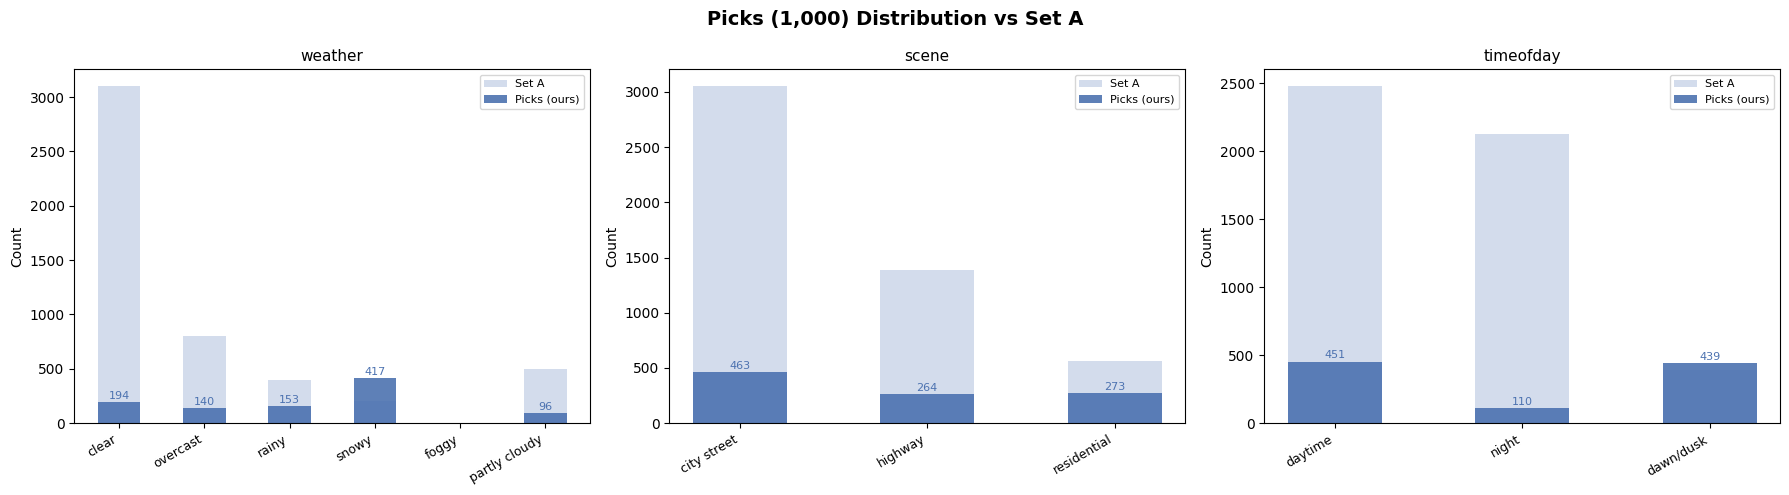

Saved: level5_picks_dist.png


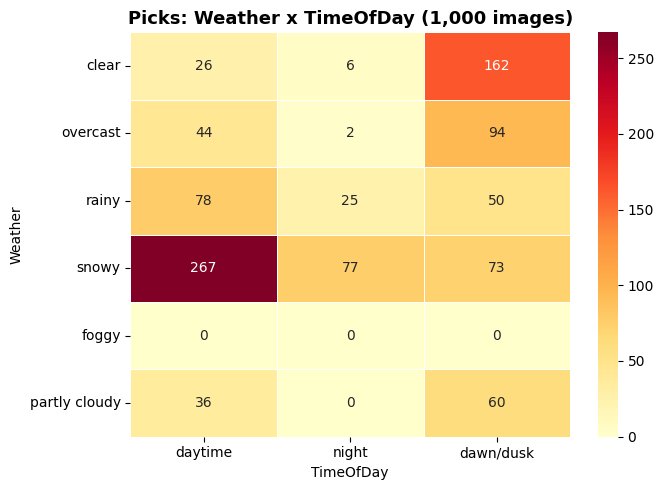

Saved: level5_heatmap.png
Random baseline checkpoint loaded: ../checkpoints/level5_random_baseline.pth

[ DI Score ]
  Random-1000 Avg-MF1 : 0.6602
  Ours (K-center)      : 0.6659  (+0.0057)
  DI Score             : 0.0086  (+0.86%)
Ablation N=250 checkpoint loaded
Ablation N=500 checkpoint loaded
Ablation N=1000 checkpoint loaded


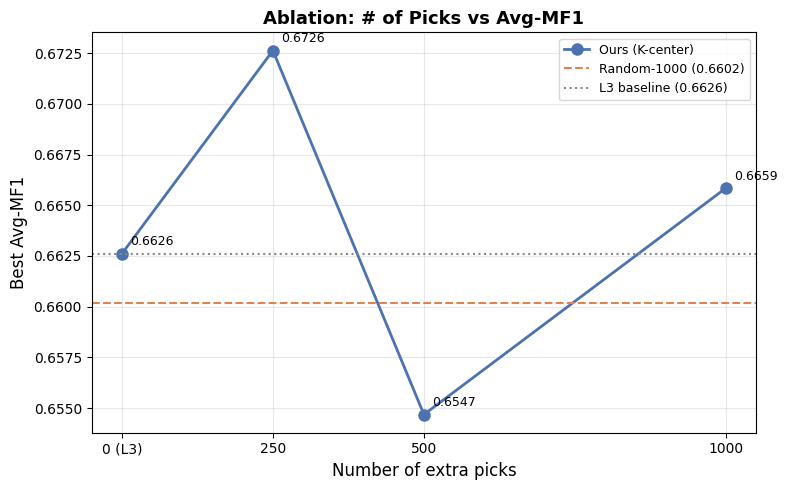

Saved: level5_ablation.png

[ Curation Report Summary ]
  Level 3 baseline    : 0.6626
  + Random 1,000      : 0.6602  (-0.24pp)
  + Ours   250 picks  : 0.6726
  + Ours   500 picks  : 0.6547
  + Ours 1,000 picks  : 0.6659  (+0.32pp)

  DI Score            : 0.0086  (+0.86%)


In [13]:

# ═══════════════════════════════════════════════════════════════════════════════
# Curation Report — 분석 셀
# ═══════════════════════════════════════════════════════════════════════════════
import json, os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch
from collections import Counter
from torch.utils.data import DataLoader, Subset

from src.datasets.bdd_attr import (BDDAttrDataset, ATTRIBUTES, NUM_CLASSES,
                                    WEATHER_CLASSES, SCENE_CLASSES, TIMEOFDAY_CLASSES)
from src.utils.metrics import collect_predictions, average_macro_f1
from src.utils.transforms import eval_transform
from src.models.resnet import resnet18

CKPT_DIR = "../checkpoints"
CLASS_LABELS = {
    "weather":   WEATHER_CLASSES,
    "scene":     SCENE_CLASSES,
    "timeofday": TIMEOFDAY_CLASSES,
}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ─── picks 로드 ───────────────────────────────────────────────────────────────
with open("../level5_picks.json") as f:
    picks_data = json.load(f)
picks = picks_data["picks"]
strategy_desc = picks_data["strategy"]

print("=" * 70)
print("[ Algorithm Summary ]")
print("=" * 70)
print(f"""
Algorithm: Class-Aware Entropy x K-Center Greedy

Step 1. Entropy-based uncertainty
        H_attr = -sum( p_i * log(p_i) ) for each head
        ent_mean = mean(H_weather, H_scene, H_timeofday)
        -> More precise than max-softmax uncertainty

Step 2. Class-aware weights (inverse proportion to Set A counts)
        snowy: 2.5 / dawn-dusk: 3.0 / residential: 2.0
        class_weight = W_weather + W_scene + W_timeofday

Step 3. Primary score S1 = class_weight x ent_mean
        Top-{3000} candidates selected

Step 4. ResNet avgpool 512-dim feature extraction

Step 5. K-Center Greedy (candidates -> final 1,000)
        * Always pick the point farthest from already-selected set
        * Ensures visual diversity across feature space
""")
print(strategy_desc)
print()

# ─── ① Picks 분포: Bar Chart ─────────────────────────────────────────────────
SET_A_CNT = {
    "weather":   [3100, 800, 400, 200, 0, 500],
    "scene":     [3052, 1386, 562],
    "timeofday": [2479, 2129, 392],
}

picks_cnt = {
    a: Counter(p[a] for p in picks) for a in ATTRIBUTES
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Picks (1,000) Distribution vs Set A", fontsize=14, fontweight="bold")

colors_picks = "#4c72b0"
colors_seta  = "#c8d4e8"

for ax, attr in zip(axes, ATTRIBUTES):
    labels  = CLASS_LABELS[attr]
    n_cls   = len(labels)
    x       = np.arange(n_cls)
    seta_c  = [SET_A_CNT[attr][i] for i in range(n_cls)]
    picks_c = [picks_cnt[attr].get(i, 0) for i in range(n_cls)]

    ax.bar(x, seta_c, color=colors_seta, label="Set A", width=0.5, alpha=0.8)
    ax.bar(x, picks_c, color=colors_picks, label="Picks (ours)", width=0.5, alpha=0.9)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=9)
    ax.set_title(attr, fontsize=11)
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)

    for xi, pc in zip(x, picks_c):
        if pc > 0:
            ax.text(xi, pc + 10, str(pc), ha="center", va="bottom", fontsize=8, color=colors_picks)

plt.tight_layout()
plt.savefig(f"{CKPT_DIR}/level5_picks_dist.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: level5_picks_dist.png")

# ─── ② Weather × TimeOfDay Heatmap ───────────────────────────────────────────
heatmap = np.zeros((len(WEATHER_CLASSES), len(TIMEOFDAY_CLASSES)), dtype=int)
for p in picks:
    heatmap[p["weather"], p["timeofday"]] += 1

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(heatmap, annot=True, fmt="d", cmap="YlOrRd",
            xticklabels=TIMEOFDAY_CLASSES,
            yticklabels=WEATHER_CLASSES, ax=ax, linewidths=0.4)
ax.set_title("Picks: Weather x TimeOfDay (1,000 images)", fontsize=13, fontweight="bold")
ax.set_xlabel("TimeOfDay"); ax.set_ylabel("Weather")
plt.tight_layout()
plt.savefig(f"{CKPT_DIR}/level5_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: level5_heatmap.png")

# ─── ③ Random-1000 Baseline + DI Score ───────────────────────────────────────
RANDOM_CKPT = f"{CKPT_DIR}/level5_random_baseline.pth"

val_ds     = BDDAttrDataset("../data/set_a", "val", transform=eval_transform())
loader_val = DataLoader(val_ds, batch_size=64, shuffle=False, num_workers=2)
set_b      = BDDAttrDataset("../data/set_b", split="mining", transform=eval_transform())

if os.path.exists(RANDOM_CKPT):
    print(f"Random baseline checkpoint loaded: {RANDOM_CKPT}")
    rc = torch.load(RANDOM_CKPT, map_location=device, weights_only=False)
    model_r = resnet18().to(device)
    model_r.load_state_dict(rc["state_dict"])
    model_r.eval()
    random_mf1 = max(rc["history"]["val_avg_mf1"])
else:
    print("Training random baseline (1,000 random picks)...")
    from src.losses.imbalanced import FocalLoss, ClassBalancedLoss
    from src.augment.mix import mixup_data, mixed_loss
    from src.utils.seed import set_seed, seed_worker
    from src.utils.transforms import train_transform
    from tqdm import tqdm

    rng = np.random.default_rng(42)
    rand_idx = rng.choice(len(set_b), 1000, replace=False)
    rand_picks = []
    for i in rand_idx:
        s = set_b.samples[i]
        rand_picks.append((s.image_id, int(s.weather), int(s.scene), int(s.timeofday)))

    train_r = BDDAttrDataset("../data/set_a", "train", transform=train_transform(), extra_picks=rand_picks)
    g = torch.Generator(); g.manual_seed(42)
    loader_r = DataLoader(train_r, batch_size=64, shuffle=True, num_workers=2,
                          worker_init_fn=seed_worker, generator=g, pin_memory=True)

    set_seed(42, deterministic=True)
    model_r = resnet18().to(device)
    base_r = torch.load(f"{CKPT_DIR}/level3_best_30ep.pth", map_location=device, weights_only=False)
    model_r.load_state_dict(base_r["state_dict"])

    EPOCHS_R = 25; LR_R = 5e-5
    samples_rs = train_r.class_counts("scene")
    loss_fns_r = {
        "weather":   FocalLoss(gamma=2.0).to(device),
        "scene":     ClassBalancedLoss(samples_rs).to(device),
        "timeofday": torch.nn.CrossEntropyLoss(),
    }
    optim_r = torch.optim.AdamW(model_r.parameters(), lr=LR_R, weight_decay=5e-4)
    sched_r = torch.optim.lr_scheduler.CosineAnnealingLR(optim_r, T_max=EPOCHS_R)

    history_r = {"train_loss": [], "val_avg_mf1": []}
    for epoch in range(EPOCHS_R):
        model_r.train()
        total_loss = 0.0
        for batch in tqdm(loader_r, desc=f"[Random {epoch+1:02d}/{EPOCHS_R}]", leave=False):
            imgs = batch["image"].to(device)
            tgts = {a: batch[a].to(device) for a in ATTRIBUTES}
            optim_r.zero_grad(set_to_none=True)
            x, ya, yb, lam = mixup_data(imgs, tgts, alpha=0.2)
            loss = mixed_loss(loss_fns_r, model_r(x), ya, yb, lam)
            loss.backward(); optim_r.step()
            total_loss += loss.item()
        sched_r.step()
        from src.utils.metrics import collect_predictions, average_macro_f1
        pv, _, tv, _ = collect_predictions(model_r, loader_val, device)
        amf1 = average_macro_f1(pv, tv)
        history_r["train_loss"].append(total_loss / len(loader_r))
        history_r["val_avg_mf1"].append(amf1)
        print(f"[Random {epoch+1:02d}/{EPOCHS_R}] val_avg_MF1={amf1:.4f}")

    torch.save({"state_dict": model_r.state_dict(), "history": history_r}, RANDOM_CKPT)
    model_r.eval()
    random_mf1 = max(history_r["val_avg_mf1"])
    print(f"Random baseline saved -> {RANDOM_CKPT}")

# 우리 picks 최종 성능
our_ckpt = torch.load(f"{CKPT_DIR}/level5_final.pth", map_location=device, weights_only=False)
our_mf1  = max(our_ckpt["history"]["val_avg_mf1"])

di_score = (our_mf1 - random_mf1) / random_mf1

print("\n" + "=" * 50)
print("[ DI Score ]")
print("=" * 50)
print(f"  Random-1000 Avg-MF1 : {random_mf1:.4f}")
print(f"  Ours (K-center)      : {our_mf1:.4f}  ({our_mf1 - random_mf1:+.4f})")
print(f"  DI Score             : {di_score:.4f}  ({di_score*100:+.2f}%)")
print("=" * 50)

# ─── ④ Ablation: 250 / 500 / 1000장 비교 ────────────────────────────────────
from src.losses.imbalanced import FocalLoss, ClassBalancedLoss
from src.augment.mix import mixup_data, mixed_loss
from src.utils.seed import set_seed, seed_worker
from src.utils.transforms import train_transform
from tqdm import tqdm

ablation_results = {}

for N in [250, 500, 1000]:
    ckpt_path = f"{CKPT_DIR}/level5_ablation_{N}.pth"
    if os.path.exists(ckpt_path):
        print(f"Ablation N={N} checkpoint loaded")
        ac = torch.load(ckpt_path, map_location=device, weights_only=False)
        ablation_results[N] = max(ac["history"]["val_avg_mf1"])
    else:
        print(f"Training ablation N={N}...")
        sub_picks = picks[:N]
        extra_n   = [(p["image_id"], p["weather"], p["scene"], p["timeofday"]) for p in sub_picks]
        train_n   = BDDAttrDataset("../data/set_a", "train", transform=train_transform(), extra_picks=extra_n)
        g = torch.Generator(); g.manual_seed(42)
        loader_n  = DataLoader(train_n, batch_size=64, shuffle=True, num_workers=2,
                               worker_init_fn=seed_worker, generator=g, pin_memory=True)

        set_seed(42, deterministic=True)
        model_n = resnet18().to(device)
        base_n = torch.load(f"{CKPT_DIR}/level3_best_30ep.pth", map_location=device, weights_only=False)
        model_n.load_state_dict(base_n["state_dict"])

        EPOCHS_N = 25; LR_N = 5e-5
        sn = train_n.class_counts("scene")
        loss_fns_n = {
            "weather":   FocalLoss(gamma=2.0).to(device),
            "scene":     ClassBalancedLoss(sn).to(device),
            "timeofday": torch.nn.CrossEntropyLoss(),
        }
        optim_n = torch.optim.AdamW(model_n.parameters(), lr=LR_N, weight_decay=5e-4)
        sched_n = torch.optim.lr_scheduler.CosineAnnealingLR(optim_n, T_max=EPOCHS_N)

        history_n = {"train_loss": [], "val_avg_mf1": []}
        for epoch in range(EPOCHS_N):
            model_n.train()
            total_loss = 0.0
            for batch in tqdm(loader_n, desc=f"[Abl-{N} {epoch+1:02d}/{EPOCHS_N}]", leave=False):
                imgs = batch["image"].to(device)
                tgts = {a: batch[a].to(device) for a in ATTRIBUTES}
                optim_n.zero_grad(set_to_none=True)
                x, ya, yb, lam = mixup_data(imgs, tgts, alpha=0.2)
                loss = mixed_loss(loss_fns_n, model_n(x), ya, yb, lam)
                loss.backward(); optim_n.step()
                total_loss += loss.item()
            sched_n.step()
            pv, _, tv, _ = collect_predictions(model_n, loader_val, device)
            amf1 = average_macro_f1(pv, tv)
            history_n["val_avg_mf1"].append(amf1)
            history_n["train_loss"].append(total_loss / len(loader_n))

        torch.save({"state_dict": model_n.state_dict(), "history": history_n}, ckpt_path)
        ablation_results[N] = max(history_n["val_avg_mf1"])
        print(f"  N={N}: Best Avg-MF1 = {ablation_results[N]:.4f}")
        del model_n; torch.cuda.empty_cache()

# Level 3 baseline (no extra picks)
l3_ckpt = torch.load(f"{CKPT_DIR}/level3_best_30ep.pth", map_location=device, weights_only=False)
l3_mf1  = max(l3_ckpt["history"]["val_avg_mf1"])

ns   = [0, 250, 500, 1000]
mf1s = [l3_mf1,
        ablation_results.get(250, np.nan),
        ablation_results.get(500, np.nan),
        ablation_results.get(1000, np.nan)]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ns, mf1s, "o-", color="#4c72b0", linewidth=2, markersize=8, label="Ours (K-center)")
ax.axhline(random_mf1, color="#dd8452", linestyle="--", linewidth=1.5, label=f"Random-1000 ({random_mf1:.4f})")
ax.axhline(l3_mf1,     color="#888",    linestyle=":",  linewidth=1.5, label=f"L3 baseline ({l3_mf1:.4f})")

for n, m in zip(ns, mf1s):
    if not np.isnan(m):
        ax.annotate(f"{m:.4f}", (n, m), textcoords="offset points", xytext=(6, 6), fontsize=9)

ax.set_xlabel("Number of extra picks", fontsize=12)
ax.set_ylabel("Best Avg-MF1", fontsize=12)
ax.set_title("Ablation: # of Picks vs Avg-MF1", fontsize=13, fontweight="bold")
ax.set_xticks(ns); ax.set_xticklabels(["0 (L3)", "250", "500", "1000"])
ax.grid(alpha=0.3); ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f"{CKPT_DIR}/level5_ablation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: level5_ablation.png")

# ─── 최종 요약 ────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("[ Curation Report Summary ]")
print("=" * 70)
print(f"  Level 3 baseline    : {l3_mf1:.4f}")
print(f"  + Random 1,000      : {random_mf1:.4f}  ({(random_mf1-l3_mf1)*100:+.2f}pp)")
print(f"  + Ours   250 picks  : {ablation_results.get(250, float('nan')):.4f}")
print(f"  + Ours   500 picks  : {ablation_results.get(500, float('nan')):.4f}")
print(f"  + Ours 1,000 picks  : {our_mf1:.4f}  ({(our_mf1-l3_mf1)*100:+.2f}pp)")
print(f"\n  DI Score            : {di_score:.4f}  ({di_score*100:+.2f}%)")
print("=" * 70)
